In [4]:
import os, sys
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # Disable jax preallocation for memory debugging only
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

import numpy as np
import xarray as xr
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *
import emcee
from functools import partial
import time
import visibilities_utils as vis_utils

def print_array_size_GB(array):
    num_bytes = array.size * array.dtype.itemsize
    print(f"{num_bytes / (1024**3):.4f} GB")
    
def pad_image_cube(cube, target_size=2048):
    nchan, npix, _ = cube.shape
    if npix > target_size:
        raise ValueError("Cube's dimensions are larger than target size; consider cropping instead.")
    
    pad_total = target_size - npix
    pad_before = pad_total // 2
    pad_after = pad_total - pad_before

    padded_cube = jnp.pad(cube, 
                          pad_width=((0, 0), (pad_before, pad_after), (pad_before, pad_after)),
                          mode='constant',
                          constant_values=0)
    return padded_cube

In [5]:
!nvidia-smi

Wed Apr  9 04:26:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.67                 Driver Version: 550.67         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:4F:00.0 Off |                  Off |
| 30%   25C    P8             17W /  300W |      35MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Radjax render cube

In [5]:
def render_cube_pinhole(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    images = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

# Re-use some params from CLEAN FITS file

In [6]:
fov_as = 12.0
data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
data_cube = imagecube(data_path, FOV=fov_as)
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
npix = data_cube.nxpix
beams_per_pix = data_cube.beams_per_pix

# Load visibilities data from xarray file

In [7]:
data_xr = xr.open_dataset('/scratch/ondemand28/len/data/radjax/HD_163296_CO_220GHz_XARRAY.nc')
uu = data_xr['uu'].to_numpy() # Lambda
vv = data_xr['vv'].to_numpy() # Lambda
data_re = data_xr['data_re'].to_numpy()
data_im = data_xr['data_im'].to_numpy()
weights = data_xr['weights'].to_numpy()
freqs = data_xr['freqs'].to_numpy()

nu0 = 230521497431.8133 # From MS['REF_FREQUENCY']
freqs_centered = freqs + (nu0 - freqs.mean())

# Show the array info
print(data_xr)

<xarray.Dataset> Size: 4GB
Dimensions:  (baseline: 374760, channel: 315)
Dimensions without coordinates: baseline, channel
Data variables:
    weights  (baseline) float64 3MB 2.018 1.832 1.75 ... 0.3169 0.3333 0.3476
    uu       (channel, baseline) float64 944MB -3.109e+04 ... 1.221e+05
    vv       (channel, baseline) float64 944MB 3.896e+04 ... -2.779e+05
    data_re  (channel, baseline) float64 944MB 0.317 1.156 ... 1.326 3.057
    data_im  (channel, baseline) float64 944MB -0.3264 -0.2049 ... 0.9874 0.8639
    freqs    (channel) float64 3kB 2.305e+11 2.305e+11 ... 2.305e+11 2.305e+11


# Handle frequencies selection (subsample frequencies)

In [8]:
num_select_each_side = 10
freqs_selected = np.array(freqs_centered[len(freqs_centered)//2 - num_select_each_side:len(freqs_centered)//2+num_select_each_side])
freqs_selected.shape

(20,)

In [9]:
freqs_selected 

array([2.30522266e+11, 2.30522190e+11, 2.30522113e+11, 2.30522036e+11,
       2.30521959e+11, 2.30521882e+11, 2.30521805e+11, 2.30521728e+11,
       2.30521651e+11, 2.30521574e+11, 2.30521497e+11, 2.30521421e+11,
       2.30521344e+11, 2.30521267e+11, 2.30521190e+11, 2.30521113e+11,
       2.30521036e+11, 2.30520959e+11, 2.30520882e+11, 2.30520805e+11])

In [10]:
freqs_selected_idx = np.array(np.arange(len(freqs_centered)//2 - num_select_each_side,len(freqs_centered)//2+num_select_each_side))
freqs_selected_idx

array([147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166])

# Compute the parametric model

In [11]:
################################################################################
# 1) Create the disk_params dictionary (instead of DiskFlaherty object).
################################################################################
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4, # For every H how much is CO
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)



################################################################################
# 2) Build the disk grid (z and r) for computing temperature, densities, etc.
################################################################################
resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

################################################################################
# 3) Use the functional approach to compute temperature, number density, velocity
################################################################################
temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)

nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)

velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

################################################################################
# 4) Compute column density, CO abundance, etc. (still purely functional)
################################################################################
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
# sigma_h2 = N_h2 * m_h

abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2

################################################################################
# 5) Prepare bounding box for interpolation
################################################################################
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])


2025-04-07 03:02:37.896671: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Render the parametric sky cube with radjax

computing pinhole spectral cube for a total of 20 frequencies


(20, 602, 602)

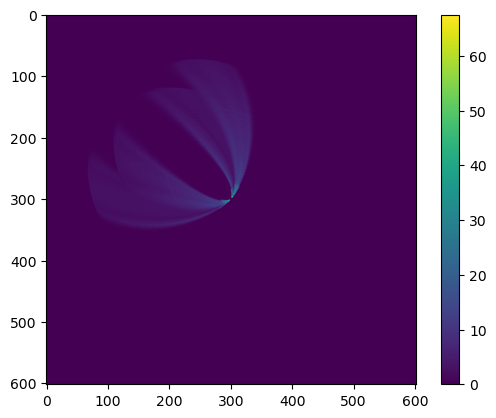

In [12]:
# freqs_selected = np.array(freqs_centered[100]) # [55,-60] | [100,-100]
projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs_selected
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / npix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

################################################################################
# 8) Render the cubes via the new functional approach
################################################################################
images = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs_selected,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)
plt.imshow(images[0])
plt.colorbar()
images.shape

In [13]:
images_padded = pad_image_cube(images, 2048)

# Create dirty image cube from visibilities

In [22]:
weights_broadcasted = np.tile(weights, (uu.shape[0], 1))

scale_factor = 1
cell_size = 0.02 * scale_factor  # [arcsec]
npix = 2048 // scale_factor 

nchan, nvis = uu.shape
# weight = jnp.ones((nchan, nvis))

weighting_type = "uniform"
append_hermitian = True

# Time this step
import time
start = time.time()

vis_grid_cuda, vis_mask_cuda, vis_cell_weight_cuda, vis_density_weight_cuda, vis_sigma = vis_utils.grid_visibilities(
    uu[freqs_selected_idx], vv[freqs_selected_idx],
    data_re[freqs_selected_idx], data_im[freqs_selected_idx],
    weights_broadcasted[freqs_selected_idx], 
    cell_size, npix, weighting=weighting_type,
    append_hermitian=append_hermitian
)

nonzero_mask = jnp.abs(vis_grid_cuda) > 0

# Get indices of nonzero pixels.
vis_nonzero_indices = jnp.nonzero(nonzero_mask)

# Move to RAM instead of holding VRAM
vis_grid, vis_mask, vis_cell_weight, vis_density_weight = jax.device_get(vis_grid_cuda), jax.device_get(vis_mask_cuda), jax.device_get(vis_cell_weight_cuda), jax.device_get(vis_density_weight_cuda)

print(f"Time taken to generate vis grid: {time.time() - start:.2f} s")

start = time.time()

MAPS_dirty_img = vis_utils.dirty_image_cube(vis_grid, weights_broadcasted[freqs_selected_idx], vis_density_weight, npix, append_hermitian)

print(f"Time taken to generate dirty image: {time.time() - start:.2f} s")

import gc

# Delete GPU-resident variables
del vis_grid_cuda
del vis_mask_cuda
del vis_cell_weight_cuda
del vis_density_weight_cuda
gc.collect()

Time taken to generate vis grid: 3.49 s
Time taken to generate dirty image: 0.35 s


0

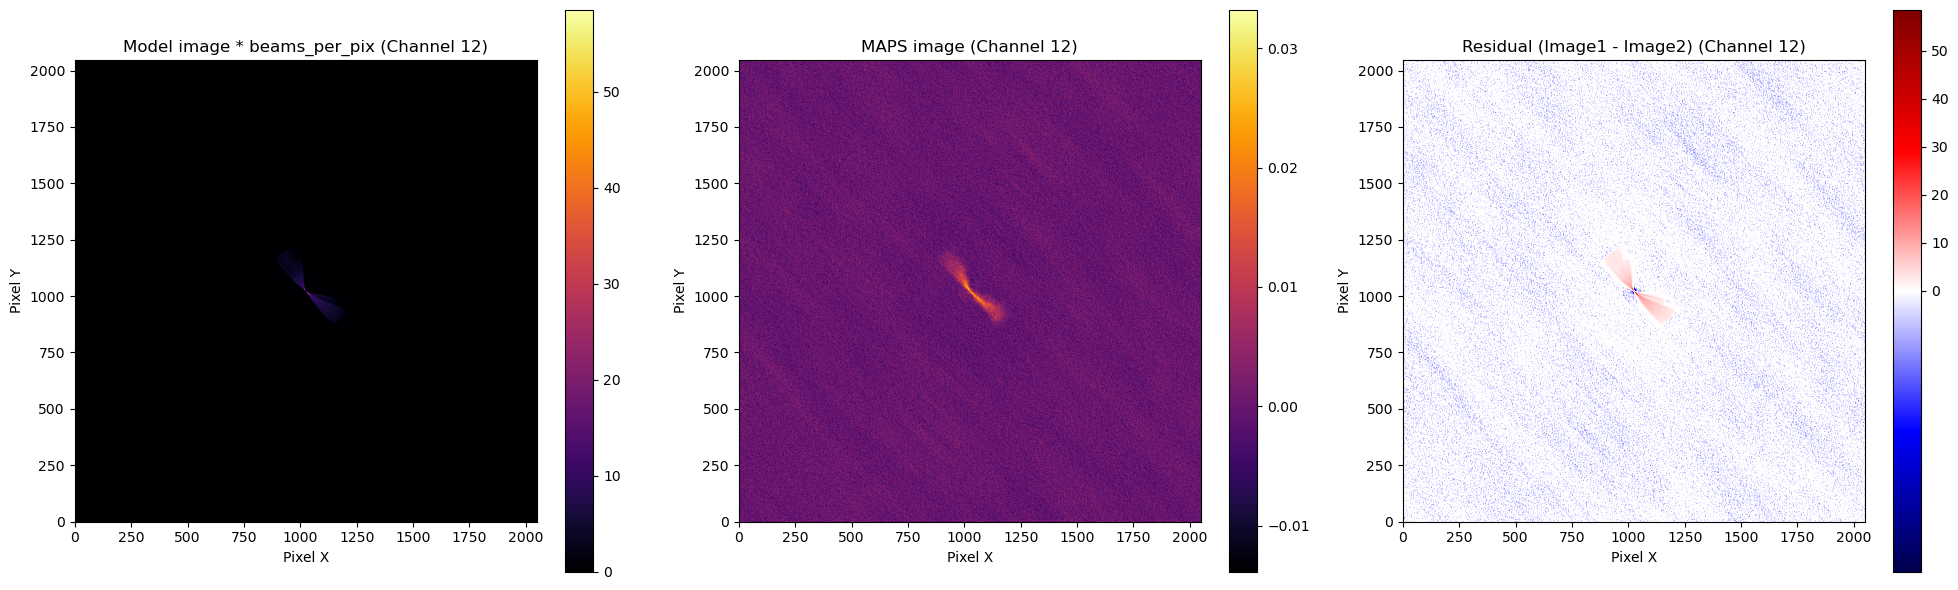

In [15]:
# beam = beams_per_pix * sensor.beam(
#     data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
# )

vis_utils.plot_channel_with_residual(images_padded,MAPS_dirty_img,12,"Model image * beams_per_pix","MAPS image")

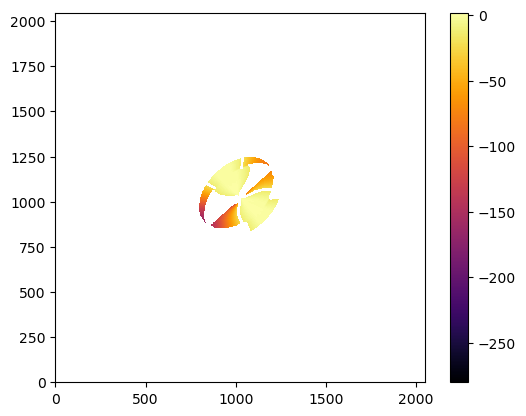

In [16]:
plt.imshow(np.log10(images_padded[12]), cmap='inferno', origin='lower')
plt.colorbar()

In [17]:
degridded_model_vis = vis_utils.image_to_gridded_visibility_cube(beams_per_pix*images_padded, weights_broadcasted[freqs_selected_idx], vis_density_weight, npix, append_hermitian)

C_temp = 1 / jnp.sum(jnp.concatenate([weights_broadcasted[freqs_selected_idx], weights_broadcasted[freqs_selected_idx]], axis=1) * vis_density_weight, axis=1)

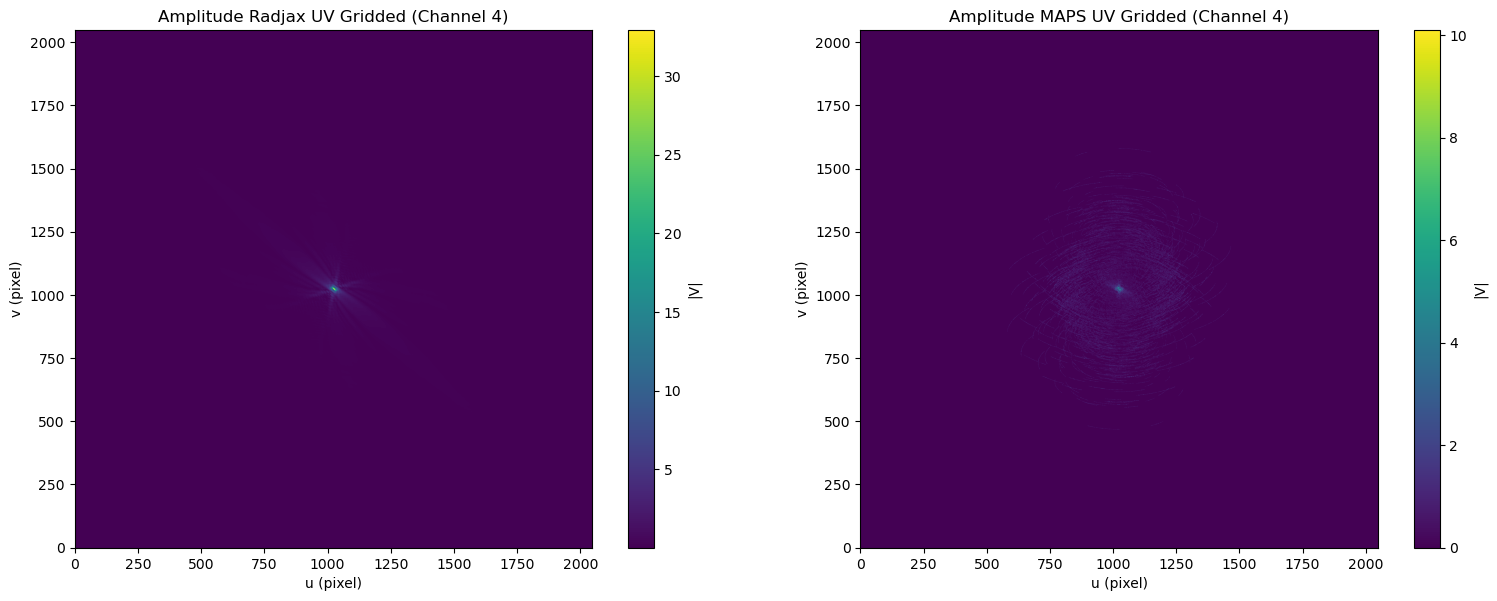

In [18]:
channel = 4  # choose a channel to visualize
# Use a logarithmic amplitude scale (adding a small epsilon to avoid log(0)).
vis_amp_radjax = np.abs(np.array(jnp.fft.fftshift(degridded_model_vis[channel])))
vis_amp_maps = np.abs(np.array(jnp.fft.fftshift(vis_grid[channel])))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(vis_amp_radjax.real, origin="lower")
axes[0].set_title(f"Amplitude Radjax UV Gridded (Channel {channel})")
axes[0].set_xlabel("u (pixel)")
axes[0].set_ylabel("v (pixel)")
plt.colorbar(im0, ax=axes[0], label="|V|")
im1 = axes[1].imshow(vis_amp_maps.real, origin="lower")
axes[1].set_title(f"Amplitude MAPS UV Gridded (Channel {channel})")
axes[1].set_xlabel("u (pixel)")
axes[1].set_ylabel("v (pixel)")
plt.colorbar(im1, ax=axes[1], label="|V|")
plt.tight_layout()

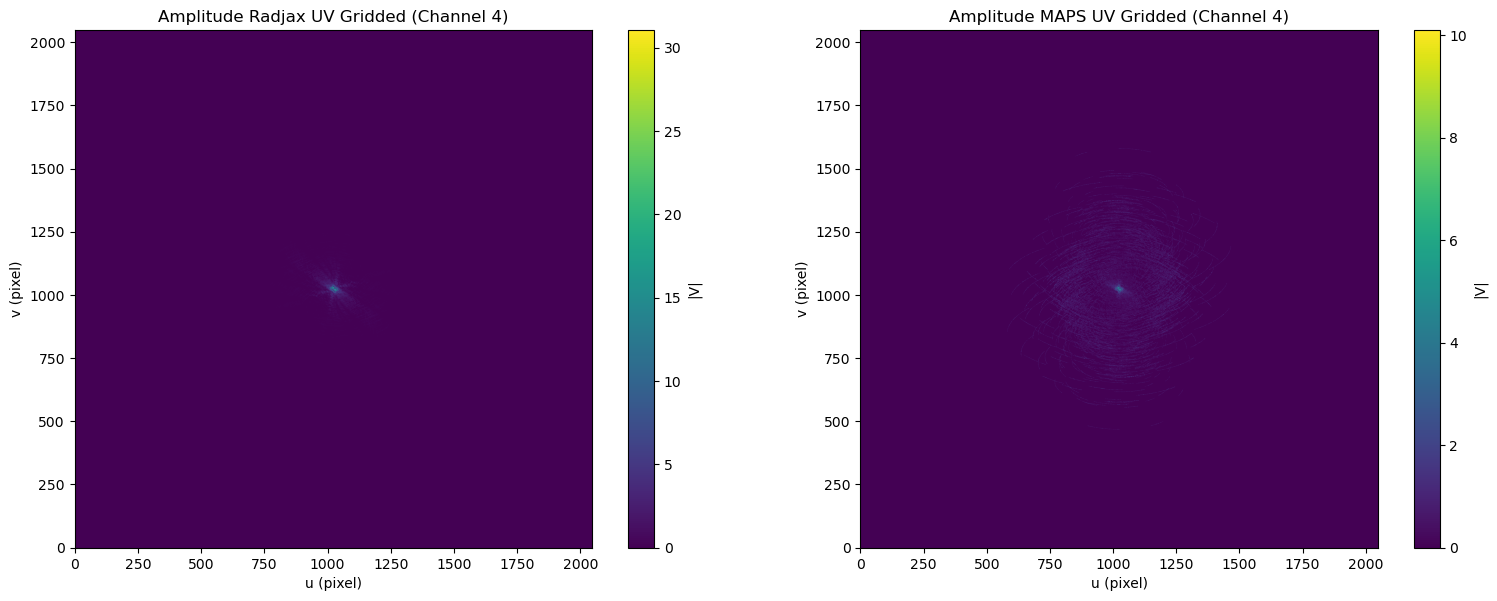

In [19]:
channel = 4  # choose a channel to visualize
# Use a logarithmic amplitude scale (adding a small epsilon to avoid log(0)).
vis_amp_radjax = np.abs(np.array(jnp.fft.fftshift(degridded_model_vis[channel] * vis_mask[channel])))
vis_amp_maps = np.abs(np.array(jnp.fft.fftshift(vis_grid[channel] * vis_mask[channel])))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(vis_amp_radjax, origin="lower")
axes[0].set_title(f"Amplitude Radjax UV Gridded (Channel {channel})")
axes[0].set_xlabel("u (pixel)")
axes[0].set_ylabel("v (pixel)")
plt.colorbar(im0, ax=axes[0], label="|V|")
im1 = axes[1].imshow(vis_amp_maps, origin="lower")
axes[1].set_title(f"Amplitude MAPS UV Gridded (Channel {channel})")
axes[1].set_xlabel("u (pixel)")
axes[1].set_ylabel("v (pixel)")
plt.colorbar(im1, ax=axes[1], label="|V|")
plt.tight_layout()

In [2]:
import jax.scipy as jsp

vis_grid_loose_pixels = vis_grid[vis_nonzero_indices]
degridded_model_vis_loose_pixels = degridded_model_vis[vis_nonzero_indices]
sigma_loose_pixels = vis_sigma[vis_nonzero_indices]

jsp.stats.norm.logpdf(jnp.real(degridded_model_vis_loose_pixels[channel]), jnp.real(vis_grid_loose_pixels[channel]), sigma_loose_pixels[channel])

NameError: name 'vis_grid' is not defined

In [24]:
jsp.stats.norm.logpdf(jnp.imag(degridded_model_vis_loose_pixels[channel]), jnp.imag(vis_grid_loose_pixels[channel]), sigma_loose_pixels[channel])

Array(-1111.89237989, dtype=float64)